
Aurélie BIAOU



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### PART A

Importing the libraries to work on the files and execute certain codes.

In [2]:
#Loading the dataset
df = pd.read_csv('data/HepatitisCdata.csv')

# The first column ("Unnamed: 0") is only the row number of the file, not a patient variable.
# The file is sorted by Category, so keeping it would give the answer to the models : I remove it.
df = df.drop(columns=['Unnamed: 0'])

I load the data in df with pandas.
I also remove the first column, which is only the row number of the file. Since the rows are sorted by category (blood donors first, then the patients), this column would "leak" the answer to the models.

In [3]:
df.head()

,Category,Age,Sex,ALB,ALP,ALT,AST,BIL,CHE,CHOL,CREA,GGT,PROT
0,0=Blood Donor,32,m,38.5,52.5,7.7,22.1,7.5,6.93,3.23,106.0,12.1,69.0
1,0=Blood Donor,32,m,38.5,70.3,18.0,24.7,3.9,11.17,4.80,74.0,15.6,76.5
2,0=Blood Donor,32,m,46.9,74.7,36.2,52.6,6.1,8.84,5.20,86.0,33.2,79.3
3,0=Blood Donor,32,m,43.2,52.0,30.6,22.6,18.9,7.33,4.74,80.0,33.8,75.7
4,0=Blood Donor,32,m,39.2,74.1,32.6,24.8,9.6,9.15,4.32,76.0,29.9,68.7


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 615 entries, 0 to 614
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Category  615 non-null    str    
 1   Age       615 non-null    int64  
 2   Sex       615 non-null    str    
 3   ALB       614 non-null    float64
 4   ALP       597 non-null    float64
 5   ALT       614 non-null    float64
 6   AST       615 non-null    float64
 7   BIL       615 non-null    float64
 8   CHE       615 non-null    float64
 9   CHOL      605 non-null    float64
 10  CREA      615 non-null    float64
 11  GGT       615 non-null    float64
 12  PROT      614 non-null    float64
dtypes: float64(10), int64(1), str(2)
memory usage: 62.6 KB


In [5]:
df.describe()

,Age,ALB,ALP,ALT,AST,BIL,CHE,CHOL,CREA,GGT,PROT
count,615.000000,614.000000,597.000000,614.000000,615.000000,615.000000,615.000000,605.000000,615.000000,615.000000,614.000000
mean,47.408130,41.620195,68.283920,28.450814,34.786341,11.396748,8.196634,5.368099,81.287805,39.533171,72.044137
std,10.055105,5.780629,26.028315,25.469689,33.090690,19.673150,2.205657,1.132728,49.756166,54.661071,5.402636
min,19.000000,14.900000,11.300000,0.900000,10.600000,0.800000,1.420000,1.430000,8.000000,4.500000,44.800000
25%,39.000000,38.800000,52.500000,16.400000,21.600000,5.300000,6.935000,4.610000,67.000000,15.700000,69.300000
50%,47.000000,41.950000,66.200000,23.000000,25.900000,7.300000,8.260000,5.300000,77.000000,23.300000,72.200000
75%,54.000000,45.200000,80.100000,33.075000,32.900000,11.200000,9.590000,6.060000,88.000000,40.200000,75.400000
max,77.000000,82.200000,416.600000,325.300000,324.000000,254.000000,16.410000,9.670000,1079.100000,650.900000,90.000000


#1
The dataset have 615 patients and 13 columns : the target class (Category) and 12 variables (age, sex and 10 biomarkers),
The different value gap is logical with the fact that we have patients at different stages of the disease.
We can see a big difference between the min value and the maximum value of ALT(min :0.9, max :325).

Now we will identify missing values/datas.
By checking the describe output , we can see that there in the line min , there is no 0 values wich would not be accurate to the expcted values for the attributes.

In [6]:
# 2. Identify missing values
df.isnull().sum()

Category     0
Age          0
Sex          0
ALB          1
ALP         18
ALT          1
AST          0
BIL          0
CHE          0
CHOL        10
CREA         0
GGT          0
PROT         1
dtype: int64

We are missing values for ALP (18), CHOL (10), ALB (1), ALT (1), PROT (1).

To handle these missing data i choose to replace them with the median rather than the mean because the median will be more representative of a real-life data and not symetrical like the mean.

To avoid data leakage, the medians are computed on the training set only, after the train/test split (step 9 in Part B). This way, no information from the test set or from the target class is used to fill the missing values.

In [7]:
# The imputation itself is done after the split (step 9) to avoid data leakage
numerical_cols = ['ALB', 'ALP', 'ALT', 'AST', 'BIL', 'CHE', 'CHOL', 'CREA', 'GGT', 'PROT']
print('Columns with missing values :', [col for col in numerical_cols if df[col].isnull().sum() > 0])

Columns with missing values : ['ALB', 'ALP', 'ALT', 'CHOL', 'PROT']


At first I filled these values with the median of each class. But this uses the target (Category) to complete the features, which is a form of data leakage : the model would indirectly "see" the answer. I now use a simple median, learned on the training set only.

In [8]:
# 3. Encoding the sex variable
df['Sex'] = df['Sex'].map({'m': 1, 'f': 0})

print('Encoding Sex :')
print(df['Sex'].value_counts())
print('\nAfter encoding :')
display(df[['Sex', 'Category']].head(5))

Encoding Sex :
Sex
1    377
0    238
Name: count, dtype: int64

After encoding :


,Sex,Category
0,1,0=Blood Donor
1,1,0=Blood Donor
2,1,0=Blood Donor
3,1,0=Blood Donor
4,1,0=Blood Donor


Sex could be a clinically important variable in case the gender have an impact on the risks of developping the disease.
In the code we put male as class 1 and female as class 0.
We can see in the output of the encoding that class 1 (males, 377) is higher than class 0 (females, 238).


=== CLASS DISTRIBUTION ===
Category
0=Blood Donor             533
3=Cirrhosis                30
1=Hepatitis                24
2=Fibrosis                 21
0s=suspect Blood Donor      7
Name: count, dtype: int64

Ratio MAX/MIN : 76.1x


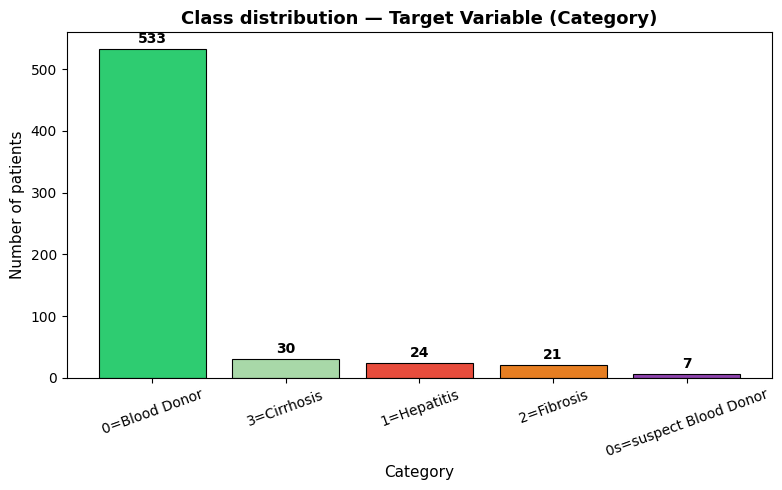

In [9]:
# 4a. Distribution of the target variable (Category)
print('=== CLASS DISTRIBUTION ===')
class_counts = df['Category'].value_counts()
print(class_counts)
print(f'\nRatio MAX/MIN : {class_counts.iloc[0] / class_counts.iloc[-1]:.1f}x')

# Visualization of the class distribution
fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#2ecc71', '#a8d8a8', '#e74c3c', '#e67e22', '#8e44ad']
bars = ax.bar(class_counts.index, class_counts.values, color=colors, edgecolor='black', linewidth=0.8)
ax.set_title('Class distribution — Target Variable (Category)', fontsize=13, fontweight='bold')
ax.set_xlabel('Category', fontsize=11)
ax.set_ylabel('Number of patients', fontsize=11)
for bar, val in zip(bars, class_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            str(val), ha='center', va='bottom', fontweight='bold')
ax.tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.show()


**Distirbution of the target variable **
- Blood Donor : 533 (86.7%)
- Cirrhosis : 30,
- Hepatitis : 24,
- Fibrosis : 21,
- Suspect BD : 7  

The max and minimum ration is around **76.1** between the blood donors and the suspect blood donors

This imbalance coulb be coherent as in generalized population healthy donors make up the majority.
However we saw in previous lab activities that a big imbalance in machine learning can lead models to only predict the majority class by default (here our majority class would be blood donors and the minority is suspect blood donors).
In the end the model accuracy could be high but still gives false negatives predictions (no detection of diseases).
In a biomdical context, false negatives are really dangerous as it would lead sick patients to believe they are healthy.
To handle that, we use balanced class weights in the models (class_weight='balanced') rather than removing data, to increase the model's prediction performance on the small classes.


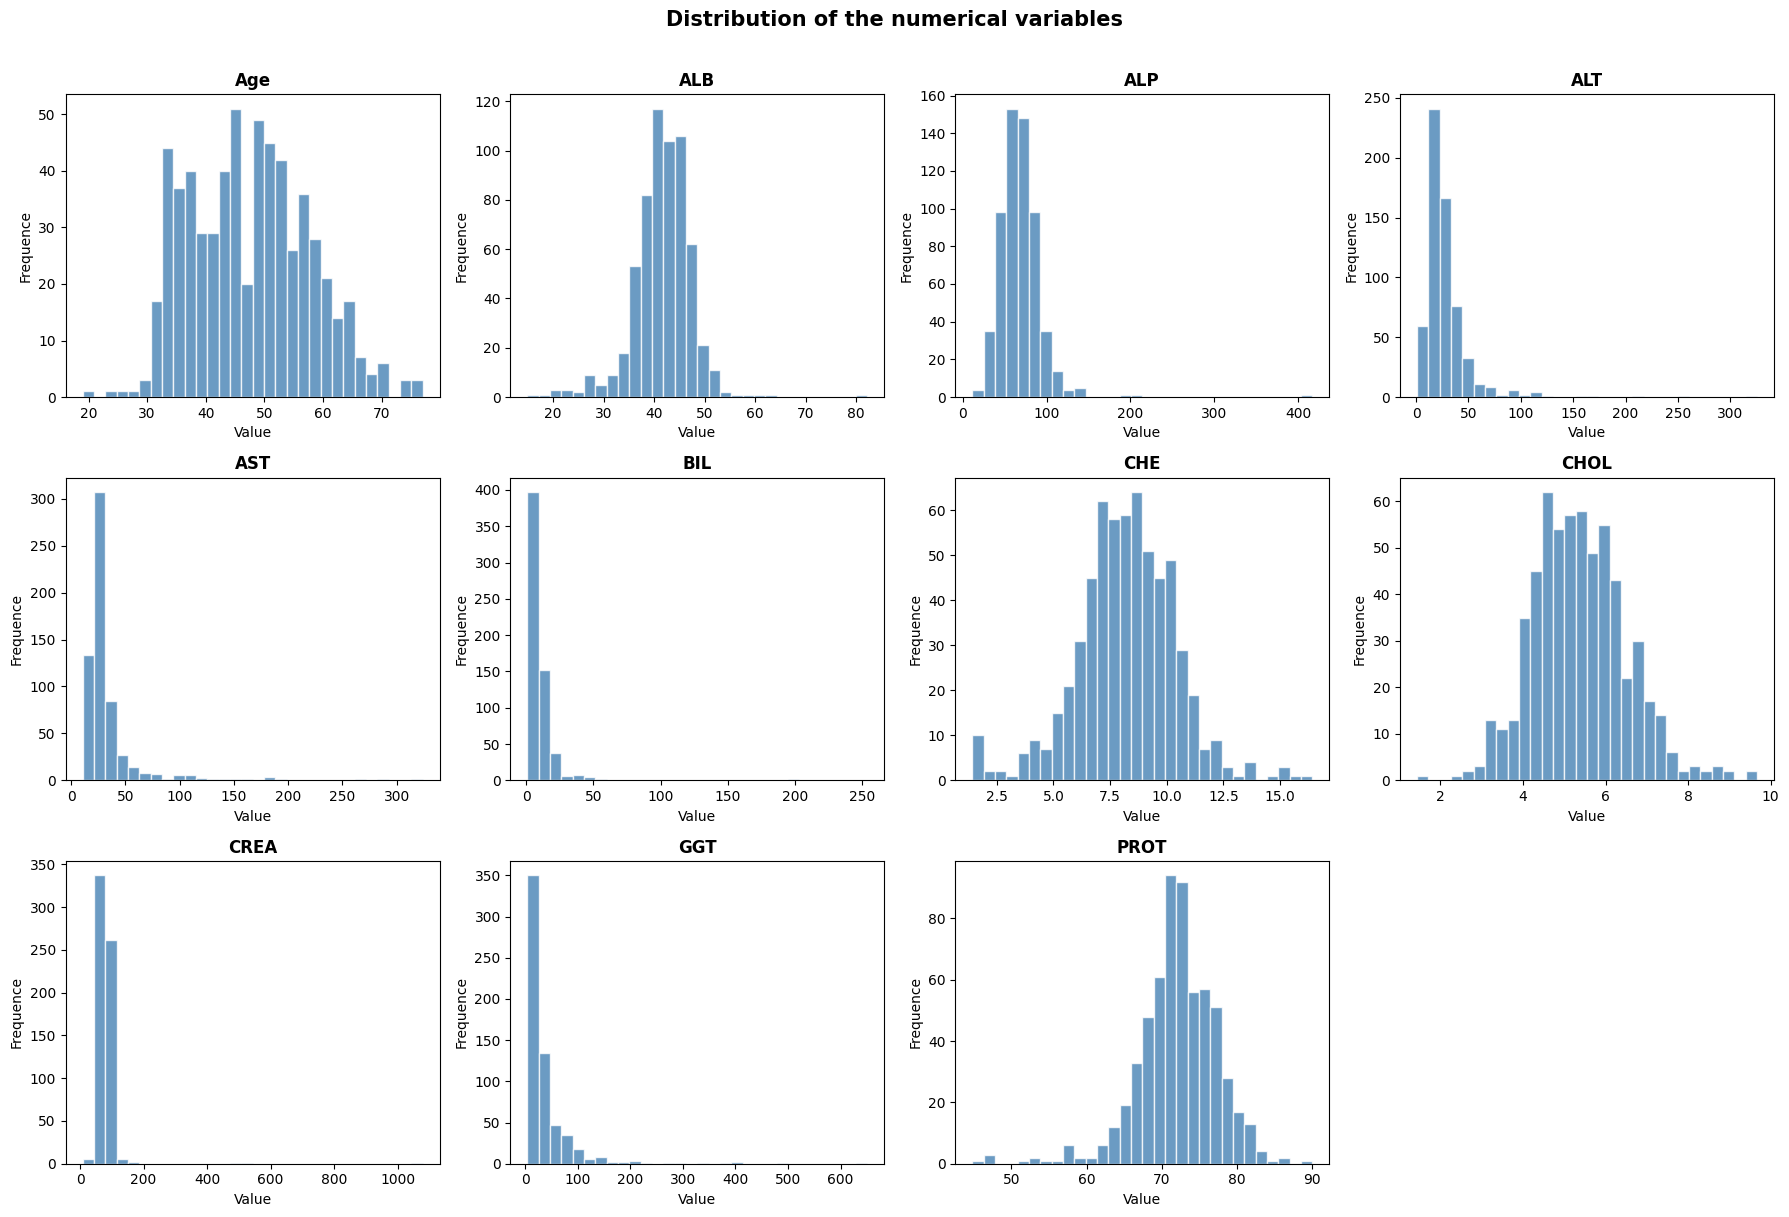

In [10]:
# 4b.Distribution of the numerical variables
fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(['Age', 'ALB', 'ALP', 'ALT', 'AST', 'BIL', 'CHE', 'CHOL', 'CREA', 'GGT', 'PROT']):
    axes[i].hist(df[col].dropna(), bins=30, color='steelblue', edgecolor='white', alpha=0.8)
    axes[i].set_title(col, fontweight='bold')
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Frequence')

axes[-1].axis('off')
fig.suptitle('Distribution of the numerical variables', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

**Distribution of the numerical values:**
- ALT, AST, BIL, and GGT presents really right skewed distributions wich means the majority of the values are low (healthy donors).But some values are very high (probably the patient with the most advanced stages of the disease)

-For ALB, CHOL, and PROT the distribution is more symetrical wich could represent a stable  level of proteins for healthy patients.

The Age grpah show a spread out distribution because of the sample's diversity.


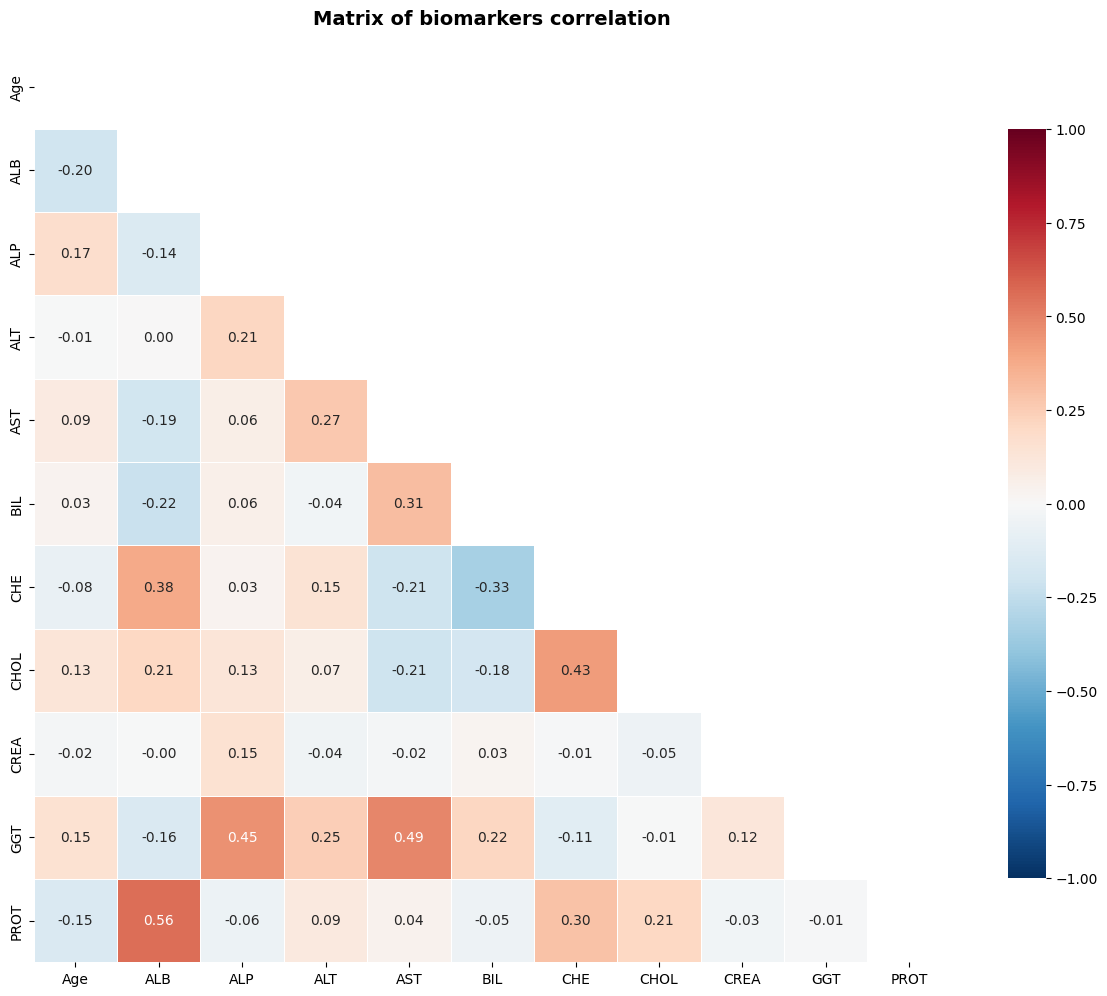

In [11]:
# 5. Correlation analysis
# Calcul and visualisation of the correlation matrix between the numerical values
# The correlation measures the strength and the direction of the linear relation
# between two variables (coefficient between -1 and +1).
# ─────────────────────────────────────────────────────────────────────────────
num_cols_for_corr = ['Age', 'ALB', 'ALP', 'ALT', 'AST', 'BIL', 'CHE', 'CHOL', 'CREA', 'GGT', 'PROT']
corr_matrix = df[num_cols_for_corr].corr()

plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    vmin=-1, vmax=1,
    linewidths=0.5,
    square=True,
    cbar_kws={'shrink': 0.8}
)
plt.title('Matrix of biomarkers correlation', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()


The correlation matrix mesures the force and the direction of the linear relations between two variables.
Here it highlights several biologically expected relationships between key liver biomarkers, supporting both the clinical importance of the variables and their coherence with the dataset.

The strongest positive correlation is observed between **ALB and PROT** (0.56). Albumin is the main protein of the blood and it is produced by the liver, so it is logical that it follows the level of total proteins.

**AST and GGT** (0.49) and **ALP and GGT** (0.45) also show moderate positive correlations. These enzymes increase when liver cells or bile ducts are damaged, so they tend to rise together in liver diseases.

The correlation between **CHE and CHOL** (0.43) and between **CHE and ALB** (0.38) reflects the liver's central role in synthesis. Since cholinesterase, cholesterol and albumin are all produced by the liver, a simultaneous decrease may indicate bad hepatic synthesis capacity.

On the other hand, **BIL and CHE** are negatively correlated (-0.33) : when the liver function gets worse, bilirubin accumulates while cholinesterase decreases.

Surprisingly, **ALT and AST** are only weakly correlated (0.27), even if these two transaminases are both released after hepatocyte damage. This can be explained by the fact that most patients are healthy donors, with low and stable values.

These correlations remain moderate (all below 0.6), so there is no strong redundancy between the variables and we can keep all of them for the models.

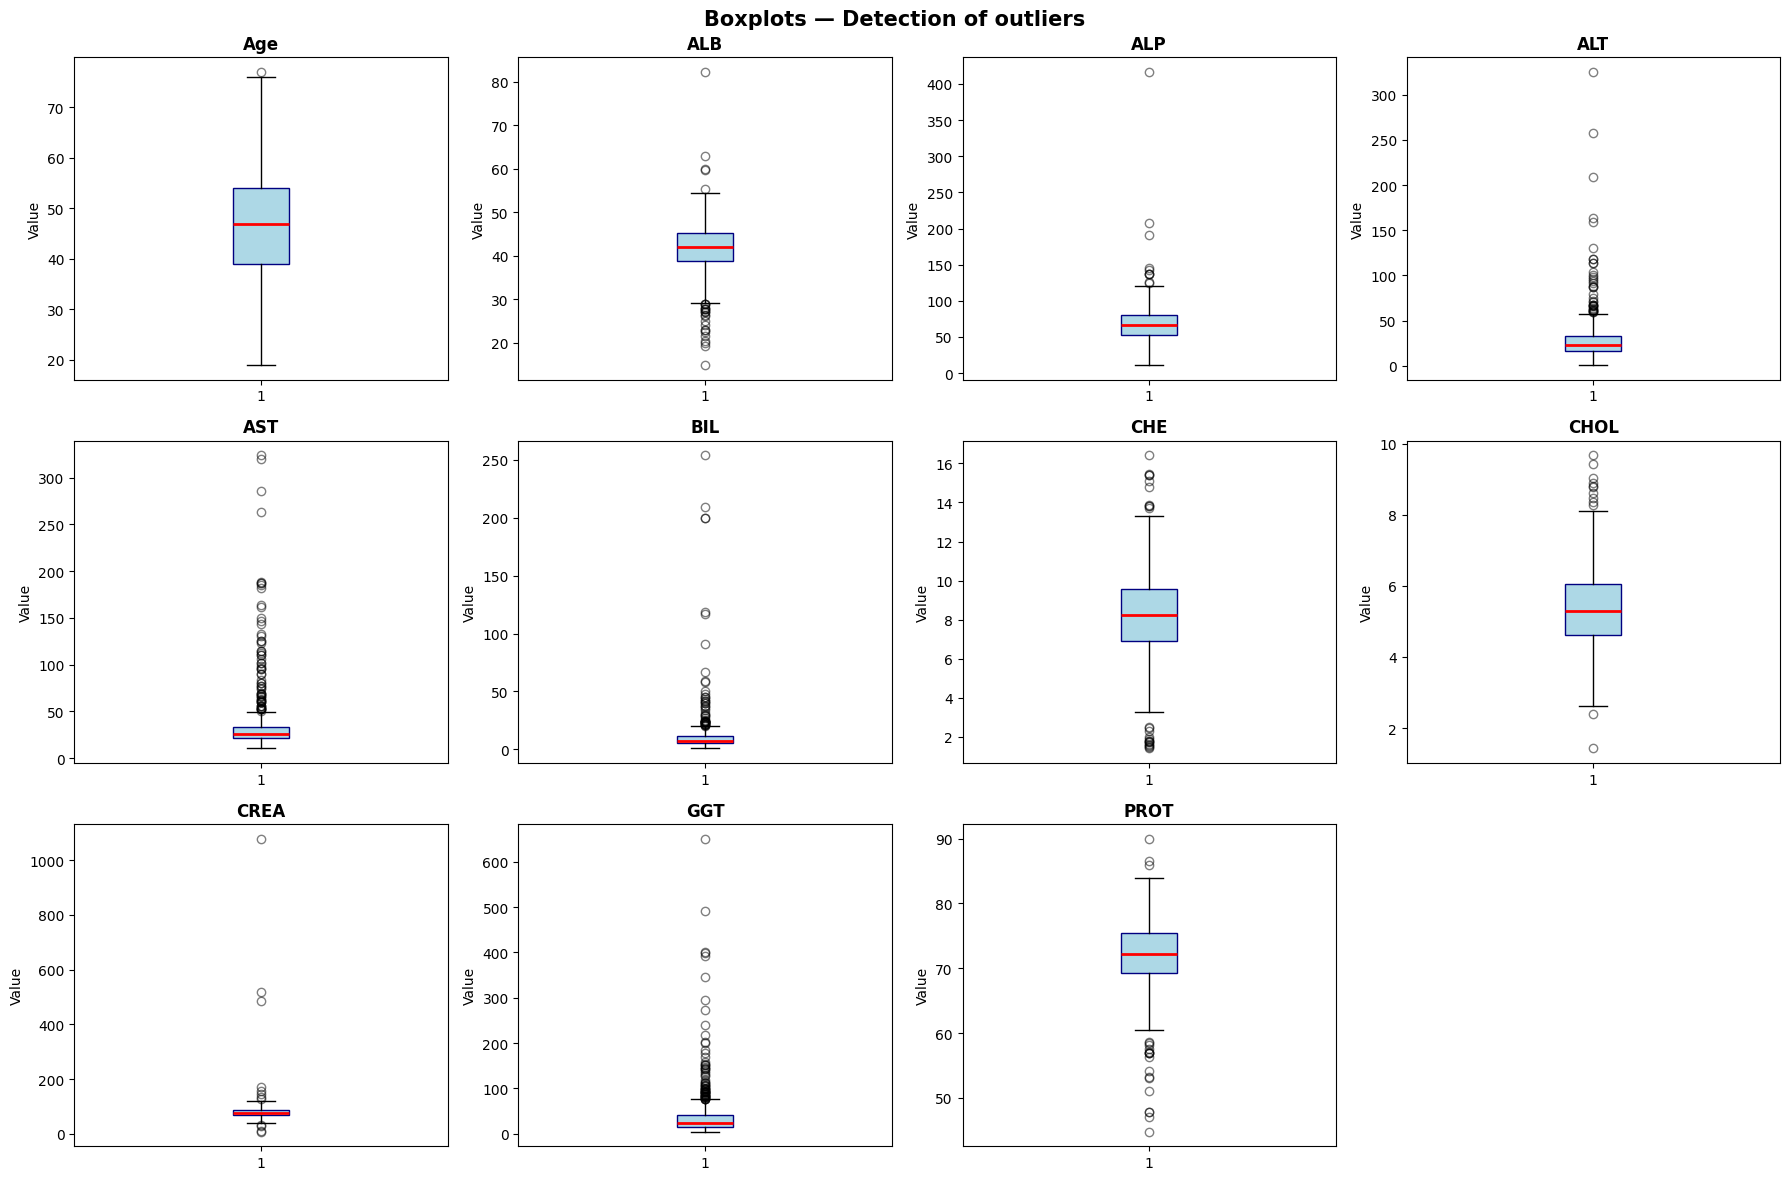

In [12]:
# 6. Check for outliers
# Visualization of the outliers with boxplot
fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(num_cols_for_corr):
    axes[i].boxplot(df[col].dropna(), vert=True, patch_artist=True,
                    boxprops=dict(facecolor='lightblue', color='navy'),
                    medianprops=dict(color='red', linewidth=2),
                    flierprops=dict(marker='o', color='tomato', alpha=0.5))
    axes[i].set_title(col, fontweight='bold')
    axes[i].set_ylabel('Value')

axes[-1].axis('off')
fig.suptitle('Boxplots — Detection of outliers', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()


The correlation matrix shows several relationships that are consistent with basic liver biology, meaning the variables behave in a way we would expect clinically.

In addition, boxplots and the IQR method highlight the presence of many extreme values (outliers) in the dataset.

For bilirubin (BIL), very high values are observed in patients with advanced liver disease, especially cirrhosis. In severe cases, bilirubin levels can become extremely elevated.

For ALT and AST, there are noticeable peaks that correspond to severe hepatitis episodes. These enzymes can rise during liver inflamation.

GGT also shows high extreme values, particularly in alcohol-related liver diseases and cirrhosis. This enzyme is often strongly elevated when there is chronic liver damage.

As for creatinine (CREA), some high outliers may be linked to patients with serious complications of advanced liver disease.

These values even the extreme ones seems medically realistic and reflect true pathological conditions. Removing all of these outliers could lead to excluding the sickest patients from the dataset, wich would not be coherent with the fact that we know our patients are on different stage of the disease the highest peaks represents the sickests patients.

In [13]:
# 7. Detect outliers using the interquartile method (IQR)
# I count them but I do NOT remove them : they correspond to the sickest patients.
df_clean = df.copy()
outlier_mask = pd.Series(False, index=df.index)

for col in num_cols_for_corr:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    col_outliers = (df[col] < lower) | (df[col] > upper)
    print(f'{col:5s} : {col_outliers.sum()} outliers')
    outlier_mask = outlier_mask | col_outliers

print(f'\nPatients with at least one outlier : {outlier_mask.sum()} ({outlier_mask.mean()*100:.1f}%)')
print('\n=== Classes of these patients ===')
print(df.loc[outlier_mask, 'Category'].value_counts())

Age   : 1 outliers
ALB   : 27 outliers
ALP   : 10 outliers
ALT   : 36 outliers
AST   : 64 outliers
BIL   : 47 outliers
CHE   : 24 outliers
CHOL  : 12 outliers
CREA  : 12 outliers
GGT   : 65 outliers
PROT  : 20 outliers

Patients with at least one outlier : 166 (27.0%)

=== Classes of these patients ===
Category
0=Blood Donor             97
3=Cirrhosis               30
2=Fibrosis                17
1=Hepatitis               15
0s=suspect Blood Donor     7
Name: count, dtype: int64


If we removed every patient with at least one outlier, we would delete 166 patients (27%), including **all** the cirrhosis patients, **all** the suspect blood donors, and most of the hepatitis and fibrosis cases. The model would then be trained almost only on healthy donors, and it could not learn to recognise the diseases.

Since these extreme values are medically realistic and correspond to the sickest patients, I keep them in the dataset (df_clean is simply a copy of df). Random Forest is not sensitive to extreme values, and for Logistic Regression the standardisation (step 9) reduces their impact.

# PART B

In [14]:
from sklearn.model_selection import train_test_split
# 8. Prepare features X and target y, then apply stratified split

X = df_clean.drop(columns=['Category'])
y = df_clean['Category']

print('X Dimensions :', X.shape)
print('Y Dimensions :')
print(y.value_counts())


# Stratified split (80% train / 20% test)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f'\nTrain test size : {X_train.shape[0]} observations')
print(f'Test set size : {X_test.shape[0]} observations')
print('\n y_train Distribution :', y_train.value_counts().to_dict())
print(' y_test Distribution :', y_test.value_counts().to_dict())

X Dimensions : (615, 12)
Y Dimensions :
Category
0=Blood Donor             533
3=Cirrhosis                30
1=Hepatitis                24
2=Fibrosis                 21
0s=suspect Blood Donor      7
Name: count, dtype: int64

Train test size : 492 observations
Test set size : 123 observations

 y_train Distribution : {'0=Blood Donor': 426, '3=Cirrhosis': 24, '1=Hepatitis': 19, '2=Fibrosis': 17, '0s=suspect Blood Donor': 6}
 y_test Distribution : {'0=Blood Donor': 107, '3=Cirrhosis': 6, '1=Hepatitis': 5, '2=Fibrosis': 4, '0s=suspect Blood Donor': 1}


Stratified splitting is essential in this context because it ensures that each class is represented proportionally in both the training and test sets. This is particularly important since some classes, such as hepatitis and fibrosis, contain very few observations.

Some groups are very small (for example, only 7 suspected donors). With a simple random split, there is a real risk that some classes might not appear at all in the test set.

By using stratification, we make sure that the model is evaluated on all classes, including the rare ones. This is especially important in a clinical context, where detecting these less frequent but critical disease stages is a key objective.

In [15]:
# 9. Handle missing values, then scale data where needed
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

# Median imputation, learned on the train set only (no data leakage)
imputer = SimpleImputer(strategy='median')
X_train_imp = pd.DataFrame(imputer.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_imp = pd.DataFrame(imputer.transform(X_test), columns=X_test.columns, index=X_test.index)

print('Missing values after imputation (train / test) :',
      int(X_train_imp.isnull().sum().sum()), '/', int(X_test_imp.isnull().sum().sum()))

scaler = StandardScaler()

# On train set only
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train_imp),
    columns=X_train.columns,
    index=X_train.index
)

# Apply the same transformation to the test set
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test_imp),
    columns=X_test.columns,
    index=X_test.index
)

print('\nVerification after normalisation (train set) :')
print(X_train_scaled.describe().loc[['mean', 'std']].round(3))

Missing values after imputation (train / test) : 0 / 0

Verification after normalisation (train set) :


        Age    Sex    ALB    ALP    ALT    AST    BIL    CHE   CHOL   CREA  \
mean  0.000 -0.000 -0.000  0.000 -0.000  0.000  0.000 -0.000  0.000  0.000   
std   1.001  1.001  1.001  1.001  1.001  1.001  1.001  1.001  1.001  1.001   

        GGT   PROT  
mean  0.000  0.000  
std   1.001  1.001  


Before scaling, I fill the missing values with the median of the **training set**, and I apply the same values to the test set. Now we can see that we don't have any missing datas anymore.

Some variables, like GGT, can reach values above 100 UI/L, while others like CHOL are much smaller, usually between 1 and 8 mmol/L. If we don’t normalize the data, the logistic regression model can struggle because the gradient descent may be unbalanced.

After normalization, all variables are on the same scale, with a mean close to 0 and a standard deviation close to 1.

In [16]:
from sklearn.linear_model import LogisticRegression
# 10. Train Logistic Regression

log_reg_model = LogisticRegression(
    class_weight='balanced',
    solver='lbfgs',
    max_iter=1000,
    random_state=42
)

log_reg_model.fit(X_train_scaled, y_train)

print('Classes :', log_reg_model.classes_)
print('Number of features :', log_reg_model.n_features_in_)

Classes : ['0=Blood Donor' '0s=suspect Blood Donor' '1=Hepatitis' '2=Fibrosis'
 '3=Cirrhosis']
Number of features : 12


For each patient, it calculates the probability of belonging to each of the five classes, then predicts the one with the highest probability.

Each biomarker is assigned a coefficient for every class, which makes it easier to understand how each variable influences the predictions.

In [17]:
from sklearn.ensemble import RandomForestClassifier

# 11. Train Random Forest

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_imp, y_train)

print('Random Forest results')
print(f'Model estimator: {rf_model.n_estimators}')
print(f'Max depth : {rf_model.max_depth}')

Random Forest results
Model estimator: 200
Max depth : 10


In [18]:
from sklearn.preprocessing import label_binarize

# 12. Make predictions using both models

# Predictions of the classes
y_pred_lr = log_reg_model.predict(X_test_scaled)
y_pred_rf = rf_model.predict(X_test_imp)

# Probabilities
y_proba_lr = log_reg_model.predict_proba(X_test_scaled)
y_proba_rf = rf_model.predict_proba(X_test_imp)

# Binarize y_test for multiclass ROC-AUC
class_names = log_reg_model.classes_
y_test_bin = label_binarize(y_test, classes=class_names)

print('Classes :', class_names)
print('Predictions LR :', y_pred_lr[:10])
print('Predictions RF :', y_pred_rf[:10])

Classes : ['0=Blood Donor' '0s=suspect Blood Donor' '1=Hepatitis' '2=Fibrosis'
 '3=Cirrhosis']
Predictions LR : ['0=Blood Donor' '0=Blood Donor' '0=Blood Donor' '0=Blood Donor'
 '0=Blood Donor' '0=Blood Donor' '0=Blood Donor' '0=Blood Donor'
 '0=Blood Donor' '0=Blood Donor']
Predictions RF : ['0=Blood Donor' '0=Blood Donor' '0=Blood Donor' '0=Blood Donor'
 '0=Blood Donor' '0=Blood Donor' '0=Blood Donor' '0=Blood Donor'
 '0=Blood Donor' '0=Blood Donor']


We successfully made our predictions.

In [19]:
from sklearn.metrics import confusion_matrix, classification_report, recall_score, f1_score, roc_auc_score

# 13. Print the confusion matrix, classification report and ROC
#  Logistic Regression evaluation

print('=' * 70)
print('LOGISTIC REGRESSION')
print('=' * 70)

cm_lr = confusion_matrix(y_test, y_pred_lr, labels=class_names)
print('\nConfusion Matrix - Logistic Regression')
print(cm_lr)
print('\nClassification Report - Logistic Regression')
print(classification_report(y_test, y_pred_lr, zero_division=0))

recall_lr_macro    = recall_score(y_test, y_pred_lr, average='macro')
recall_lr_weighted = recall_score(y_test, y_pred_lr, average='weighted')
f1_lr_macro        = f1_score(y_test, y_pred_lr, average='macro')
f1_lr_weighted     = f1_score(y_test, y_pred_lr, average='weighted')
roc_auc_lr         = roc_auc_score(y_test_bin, y_proba_lr, multi_class='ovr', average='macro')

print(f'Recall   (macro)    : {recall_lr_macro:.4f}')
print(f'Recall   (weighted) : {recall_lr_weighted:.4f}')
print(f'F1-score (macro)    : {f1_lr_macro:.4f}')
print(f'F1-score (weighted) : {f1_lr_weighted:.4f}')
print(f'ROC-AUC  (macro OvR): {roc_auc_lr:.4f}')

# Random Forest evaluation
print('\n' + '=' * 70)
print('RANDOM FOREST')
print('=' * 70)

cm_rf = confusion_matrix(y_test, y_pred_rf, labels=class_names)
print('\nConfusion Matrix - Random Forest')
print(cm_rf)
print('\nClassification Report - Random Forest')
print(classification_report(y_test, y_pred_rf, zero_division=0))

recall_rf_macro    = recall_score(y_test, y_pred_rf, average='macro')
recall_rf_weighted = recall_score(y_test, y_pred_rf, average='weighted')
f1_rf_macro        = f1_score(y_test, y_pred_rf, average='macro')
f1_rf_weighted     = f1_score(y_test, y_pred_rf, average='weighted')
roc_auc_rf         = roc_auc_score(y_test_bin, y_proba_rf, multi_class='ovr', average='macro')

print(f'Recall   (macro)    : {recall_rf_macro:.4f}')
print(f'Recall   (weighted) : {recall_rf_weighted:.4f}')
print(f'F1-score (macro)    : {f1_rf_macro:.4f}')
print(f'F1-score (weighted) : {f1_rf_weighted:.4f}')
print(f'ROC-AUC  (macro OvR): {roc_auc_rf:.4f}')

LOGISTIC REGRESSION

Confusion Matrix - Logistic Regression
[[102   0   4   0   1]
 [  0   1   0   0   0]
 [  1   0   3   1   0]
 [  0   0   0   4   0]
 [  0   1   0   1   4]]

Classification Report - Logistic Regression
                        precision    recall  f1-score   support

         0=Blood Donor       0.99      0.95      0.97       107
0s=suspect Blood Donor       0.50      1.00      0.67         1
           1=Hepatitis       0.43      0.60      0.50         5
            2=Fibrosis       0.67      1.00      0.80         4
           3=Cirrhosis       0.80      0.67      0.73         6

              accuracy                           0.93       123
             macro avg       0.68      0.84      0.73       123
          weighted avg       0.94      0.93      0.93       123

Recall   (macro)    : 0.8440
Recall   (weighted) : 0.9268
F1-score (macro)    : 0.7331
F1-score (weighted) : 0.9323
ROC-AUC  (macro OvR): 0.9835

RANDOM FOREST

Confusion Matrix - Random Forest
[[107 

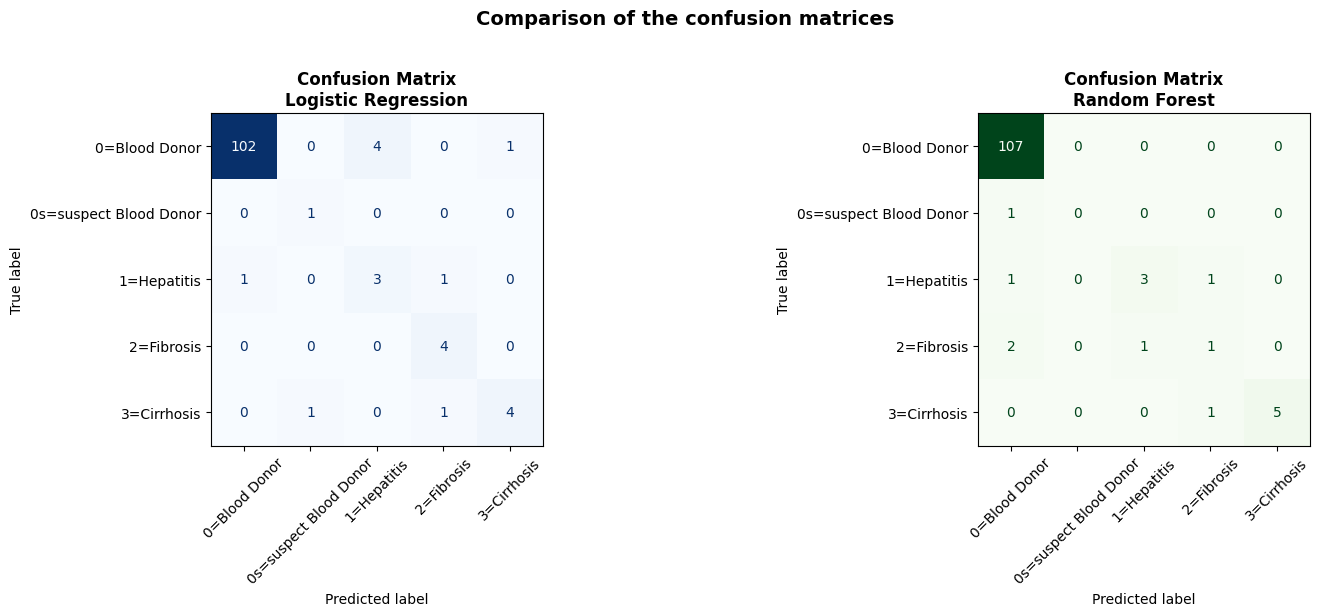

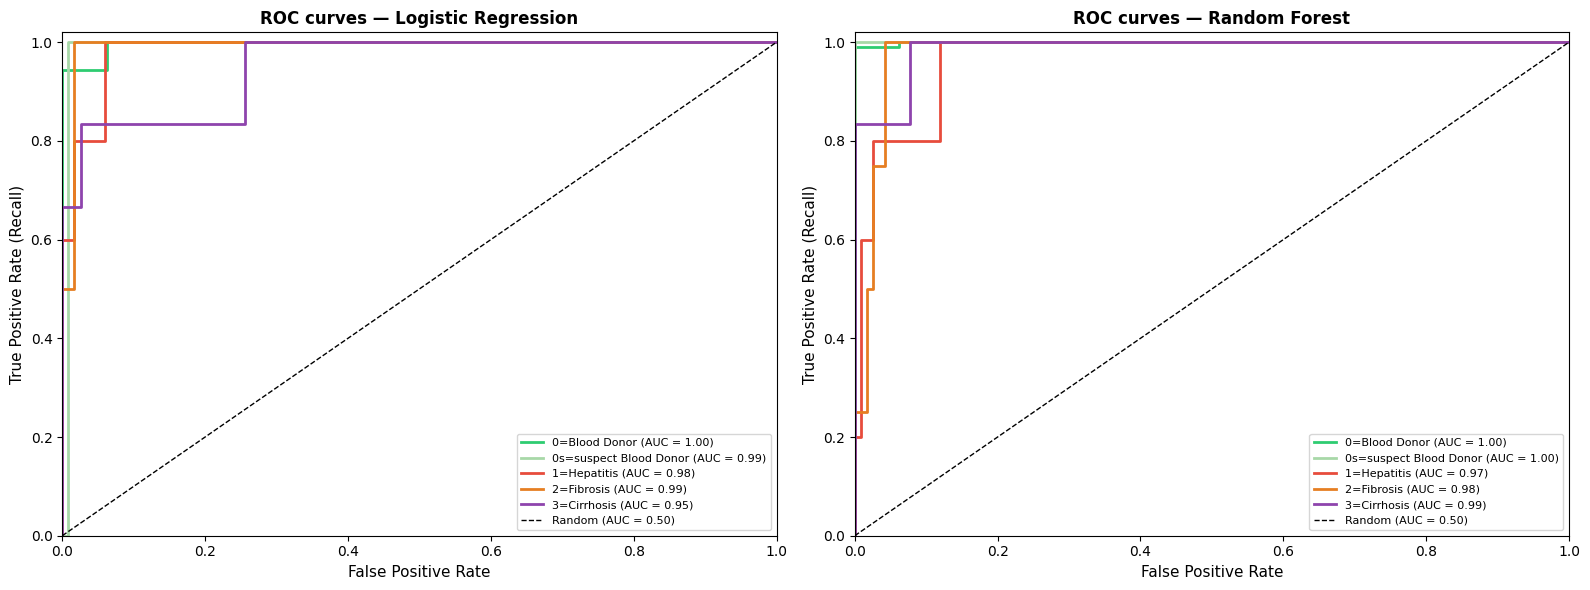

In [20]:
from sklearn.metrics import ConfusionMatrixDisplay, roc_curve, auc

# Visualization of the confusion matrix

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

disp_lr = ConfusionMatrixDisplay(confusion_matrix=cm_lr, display_labels=class_names)
disp_lr.plot(cmap='Blues', xticks_rotation=45, ax=axes[0], colorbar=False)
axes[0].set_title('Confusion Matrix\nLogistic Regression', fontsize=12, fontweight='bold')

disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=class_names)
disp_rf.plot(cmap='Greens', xticks_rotation=45, ax=axes[1], colorbar=False)
axes[1].set_title('Confusion Matrix\nRandom Forest', fontsize=12, fontweight='bold')

plt.suptitle('Comparison of the confusion matrices', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


# Multiclass ROC-AUC

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
n_classes = len(class_names)
colors_roc = ['#2ecc71', '#a8d8a8', '#e74c3c', '#e67e22', '#8e44ad']

for ax, y_proba, model_name, model_colors in [
    (axes[0], y_proba_lr, 'Logistic Regression', colors_roc),
    (axes[1], y_proba_rf, 'Random Forest', colors_roc)
]:
    for i, (class_name, color) in enumerate(zip(class_names, model_colors)):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_proba[:, i])
        roc_auc_class = auc(fpr, tpr)
        ax.plot(fpr, tpr, color=color, lw=2,
                label=f'{class_name} (AUC = {roc_auc_class:.2f})')
    ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random (AUC = 0.50)')
    ax.set_xlabel('False Positive Rate', fontsize=11)
    ax.set_ylabel('True Positive Rate (Recall)', fontsize=11)
    ax.set_title(f'ROC curves — {model_name}', fontsize=12, fontweight='bold')
    ax.legend(loc='lower right', fontsize=8)
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1.02])

plt.tight_layout()
plt.show()

In [21]:
# 13b. Robustness check : stratified 5-fold cross-validation
# The test set contains very few sick patients (only 1 suspect blood donor),
# so a single split is not enough to compare the models reliably.
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import make_pipeline

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

lr_pipeline = make_pipeline(SimpleImputer(strategy='median'), StandardScaler(),
                            LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42))
rf_pipeline = make_pipeline(SimpleImputer(strategy='median'),
                            RandomForestClassifier(n_estimators=200, max_depth=10, class_weight='balanced',
                                                   random_state=42, n_jobs=-1))

for name, pipeline in [('Logistic Regression', lr_pipeline), ('Random Forest', rf_pipeline)]:
    scores = cross_validate(pipeline, X, y, cv=cv, scoring=['recall_macro', 'f1_macro', 'roc_auc_ovr'])
    print(f'{name:20s} | Recall (macro) : {scores["test_recall_macro"].mean():.3f} +/- {scores["test_recall_macro"].std():.3f}'
          f' | F1 (macro) : {scores["test_f1_macro"].mean():.3f} +/- {scores["test_f1_macro"].std():.3f}'
          f' | ROC-AUC : {scores["test_roc_auc_ovr"].mean():.3f} +/- {scores["test_roc_auc_ovr"].std():.3f}')

Logistic Regression  | Recall (macro) : 0.682 +/- 0.106 | F1 (macro) : 0.600 +/- 0.094 | ROC-AUC : 0.910 +/- 0.053


Random Forest        | Recall (macro) : 0.537 +/- 0.109 | F1 (macro) : 0.578 +/- 0.113 | ROC-AUC : 0.983 +/- 0.008


On the test set, the two models behave differently.

**Logistic Regression detects the sick patients better.** Its macro recall is higher (0.84 against 0.54 for Random Forest), and so is its macro F1-score (0.73 against 0.57). It finds all the fibrosis patients and the suspect blood donor. The price to pay is a few false alarms : 5 healthy blood donors are predicted as sick.

**Random Forest is more "careful" with the majority class.** It classifies all the blood donors correctly and is very good on cirrhosis, but it misses the suspect blood donor and 3 of the 4 fibrosis patients, sometimes predicting them as healthy. Its decisions are pulled toward the majority class, even with balanced class weights.

Both models have a very high ROC-AUC on the test set (around 0.98), which means they rank the patients well by risk. But the test set contains very few sick patients (only 1 suspect blood donor and 4 to 6 patients per disease class), so these scores are not very stable. This is why I added a 5-fold cross-validation : it confirms that Logistic Regression has the best recall (around 0.68 against 0.54), while Random Forest has the best ROC-AUC (around 0.98 against 0.91). Random Forest ranks the patients very well, but its default decision threshold favours the "healthy" answer.

Looking at the confusion matrix, the most common mistakes happen between hepatitis and fibrosis. This is actually expected because these conditions have similar biological patterns, like moderately elevated liver enzymes. Cirrhosis is generally well classified because it has a more distinct profile, with very low cholinesterase and albumin. The "Suspect Blood Donor" group is the hardest to predict because it sits somewhere between healthy and diseased profiles, and it has only 7 patients.

In a medical context, recall (or sensitivity) is really important. Missing a sick patient (false negative) is much more serious than wrongly classifying a healthy one as sick. For this reason, Logistic Regression is the safest choice here. Random Forest could become a good option if we lowered its decision threshold for the disease classes, to take advantage of its excellent ranking ability.

### PART C

=== COEFFICIENTS Per class — LOGISTIC REGRESSION ===


,Age,Sex,ALB,ALP,ALT,AST,BIL,CHE,CHOL,CREA,GGT,PROT
0=Blood Donor,0.103,0.040,0.505,1.112,0.029,-2.564,-0.568,-0.285,0.217,-0.486,-1.095,0.140
0s=suspect Blood Donor,0.233,1.016,-0.980,0.469,0.949,0.339,-0.587,0.723,0.541,-0.086,0.137,-1.823
1=Hepatitis,-0.930,-0.383,1.061,-0.561,-0.778,0.708,0.813,0.508,0.017,-0.210,0.651,0.519
2=Fibrosis,0.462,-0.419,0.208,-0.715,-0.019,0.745,-0.100,0.542,-0.831,-0.184,0.206,0.424
3=Cirrhosis,0.133,-0.254,-0.793,-0.305,-0.181,0.772,0.442,-1.489,0.057,0.966,0.100,0.740



=== Global importance- Logistic regresion ===


,Feature,Mean_Absolute_Coefficient
5,AST,1.025464
11,PROT,0.729363
2,ALB,0.709506
7,CHE,0.709349
3,ALP,0.632440
6,BIL,0.501897
10,GGT,0.437826
1,Sex,0.422329
4,ALT,0.391190
9,CREA,0.386424


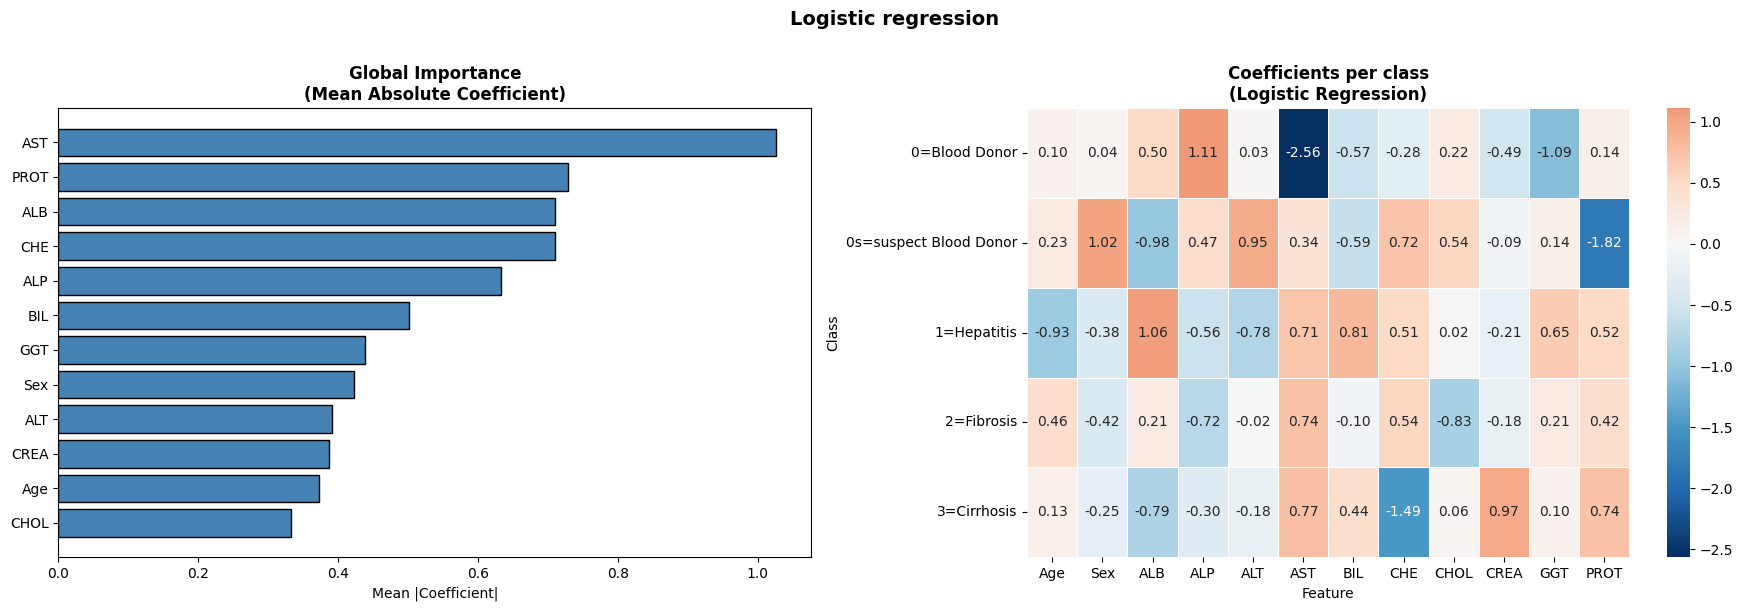

In [22]:
#14a Explainability and interpretation using feature importance


# Coefficients per class
coef_df = pd.DataFrame(
    log_reg_model.coef_,
    columns=X_train.columns,
    index=log_reg_model.classes_
)
print('=== COEFFICIENTS Per class — LOGISTIC REGRESSION ===')
display(coef_df.round(3))

#Global importance across classes
lr_feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Mean_Absolute_Coefficient': np.mean(np.abs(log_reg_model.coef_), axis=0)
}).sort_values(by='Mean_Absolute_Coefficient', ascending=False)

print('\n=== Global importance- Logistic regresion ===')
display(lr_feature_importance)

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Plot 1
axes[0].barh(lr_feature_importance['Feature'],
             lr_feature_importance['Mean_Absolute_Coefficient'],
             color='steelblue', edgecolor='black')
axes[0].invert_yaxis()
axes[0].set_title('Global Importance\n(Mean Absolute Coefficient)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Mean |Coefficient|')

# Plot 2 : heatmap
sns.heatmap(coef_df, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, linewidths=0.5, ax=axes[1])
axes[1].set_title('Coefficients per class\n(Logistic Regression)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Feature')
axes[1].set_ylabel('Class')

plt.suptitle('Logistic regression', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()



After normalization, the coefficients can be directly compared between biomarkers, which makes interpretation much easier. Some features clearly have more influence than others.

(AST) is the most important variable. It has a very strong negative coefficient for Blood Donors (-2.56) and positive coefficients for all the disease classes : a high AST pushes the model away from the healthy class. This makes sense biologically because AST is released when liver cells are damaged.

(CHE) and (ALB) are also key features. CHE has a strong negative coefficient for cirrhosis (-1.49) and ALB is also negative for cirrhosis (-0.79) : low levels of these two proteins push the model toward cirrhosis. This makes sense because they are produced by the liver, and their levels drop when the liver function worsens.

(GGT) has a negative coefficient for Blood Donors (-1.09), meaning that high GGT values make the "healthy" prediction less likely. It is often elevated in both hepatitis and cirrhosis.

(BIL) has a positive coefficient for hepatitis (0.81) and cirrhosis (0.44), meaning that higher values increase the probability of liver disease. Clinically, bilirubin is linked to jaundice which is a visible sign of liver dysfunction.

(CREA) has a positive coefficient for cirrhosis (0.97), which can be linked to kidney complications in advanced liver disease.

Finally, age, cholesterol and ALT have a smaller global impact. Sex has a high coefficient only for the suspect blood donors, but this class has only 6 patients in the training set, so this result is not reliable.

=== FEATURE IMPORTANCES — RANDOM FOREST ===


,Feature,Importance
5,AST,0.158123
2,ALB,0.147055
7,CHE,0.110293
6,BIL,0.094860
3,ALP,0.085695
11,PROT,0.080623
10,GGT,0.078065
4,ALT,0.069310
8,CHOL,0.064223
0,Age,0.058189


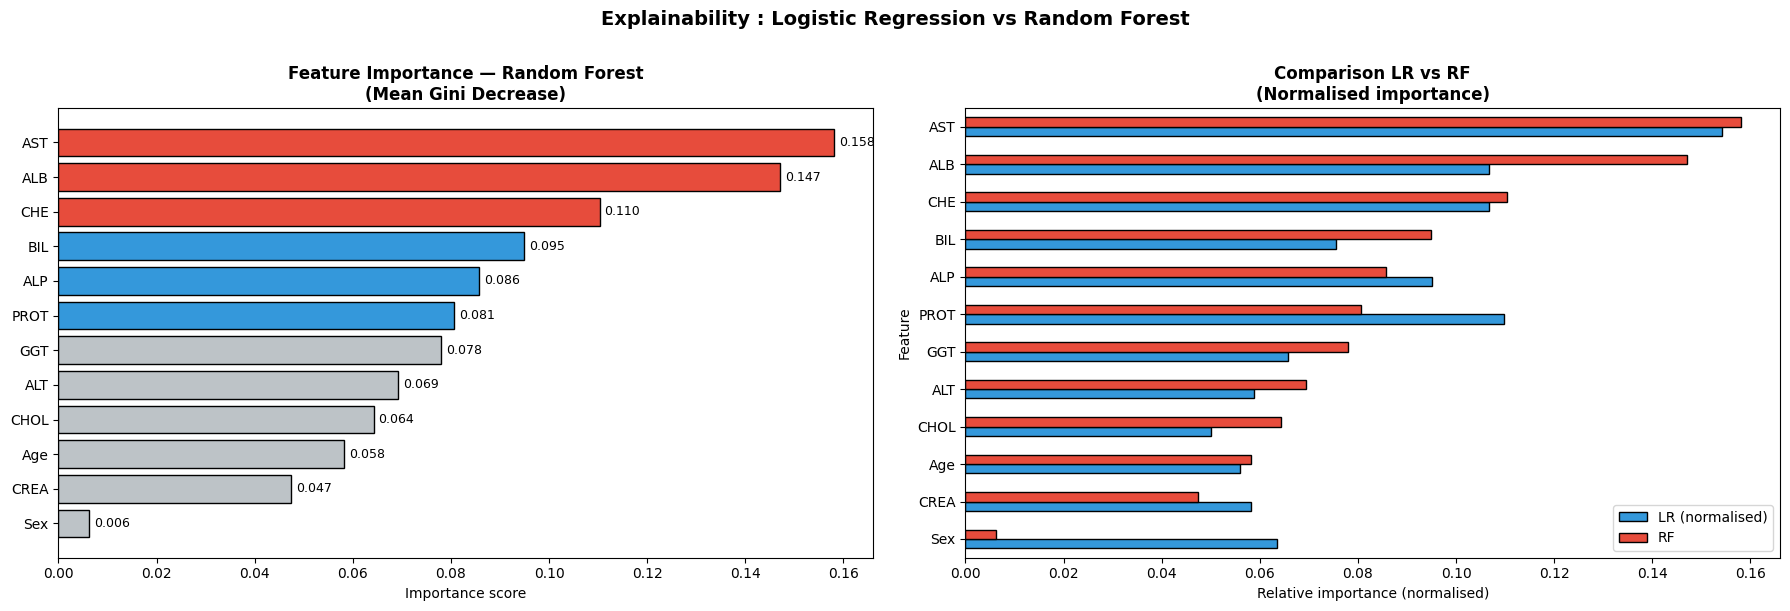

In [23]:
# Feature Importance of Random Forest


rf_feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print('=== FEATURE IMPORTANCES — RANDOM FOREST ===')
display(rf_feature_importance)


# Comparative Visualization LR vs RF

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# RF Feature Importance
palette_rf = ['#e74c3c' if i < 3 else '#3498db' if i < 6 else '#bdc3c7'
              for i in range(len(rf_feature_importance))]
axes[0].barh(rf_feature_importance['Feature'],
             rf_feature_importance['Importance'],
             color=palette_rf, edgecolor='black')
axes[0].invert_yaxis()
axes[0].set_title('Feature Importance — Random Forest\n(Mean Gini Decrease)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Importance score')
for i, (_, row) in enumerate(rf_feature_importance.iterrows()):
    axes[0].text(row['Importance'] + 0.001, i, f"{row['Importance']:.3f}",
                 va='center', fontsize=9)

# Comparison LR vs RF (normalised)
lr_imp_norm = lr_feature_importance.set_index('Feature')['Mean_Absolute_Coefficient']
lr_imp_norm = lr_imp_norm / lr_imp_norm.sum()
rf_imp_norm = rf_feature_importance.set_index('Feature')['Importance']

comparison = pd.DataFrame({'LR (normalised)': lr_imp_norm,
                            'RF': rf_imp_norm}).sort_values('RF', ascending=True)
comparison.plot(kind='barh', ax=axes[1], color=['#3498db', '#e74c3c'], edgecolor='black')
axes[1].set_title('Comparison LR vs RF\n(Normalised importance)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Relative importance (normalised)')
axes[1].legend()

plt.suptitle('Explainability : Logistic Regression vs Random Forest',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

The Random Forest model highlights the same key biomarkers as Logistic Regression, with a few differences in how it ranks them.

AST is ranked as the most important feature (0.16), followed very closely by ALB (0.15). This confirms their central role : AST reflects liver damage, while albumin reflects the liver's ability to produce proteins.

Cholinesterase (CHE) comes third (0.11). It reflects the liver's functional reserve, and its levels decrease as the disease progresses, especially in cirrhosis.

Bilirubin (BIL) also has a high importance (0.10). It's one of the most visible biomarkers clinically because high levels lead to jaundice. ALP, PROT and GGT come next, with a moderate importance.

Sex has almost no importance for Random Forest (0.006), which shows that the predictions really rely on the biological markers.

To sum up : both models agree on the most important biomarkers, AST, albumin and cholinesterase, and Random Forest also gives a strong weight to bilirubin. This is consistent with clinical practice, where these markers are commonly used to assess liver damage, liver function and disease severity. It also shows why removing the row-number column was essential : in the first version of this notebook, this column was wrongly the most important "feature".